In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [3]:
df = pd.read_csv('smartphone_cleaned_v4.csv')

In [4]:
df.shape

(980, 25)

In [5]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,1,100.0,12.0,256.0,6.70,1440 x 3216,120,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,33.0,6.0,128.0,6.59,1080 x 2412,120,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,5000.0,1,15.0,4.0,64.0,6.60,1080 x 2408,90,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,NaN,6.0,128.0,6.55,1080 x 2400,120,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,5000.0,1,67.0,6.0,128.0,6.70,1080 x 2412,120,3,1.0,android,108.0,16.0,0,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    float64

In [7]:
# Null values in columns
df.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                       101
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
resolution                     0
refresh_rate                   0
num_rear_cameras               0
num_front_cameras              4
os                             0
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                473
dtype: int64

## Column Types

- **Numerical** - Price, Rating, num_cores, 
processor_speed, battery_capacity, fast_charging_available, fast_charging, ram_capacity, internal_memory, screen_size, refresh_rate, num_rear_cameras, num_front_cameras,, primary_camera_rear, primary_camera_front, extended_memory_available, extended_upto   
- **Categorical** - brand_name, processor_brand, os 
- **Mixed** - model, resolution

## Univariate Analysis

### Categorical Columns

#### brand_name
**conclusions**

- xiaomi & samsung dominating the market 

<Axes: xlabel='brand_name'>

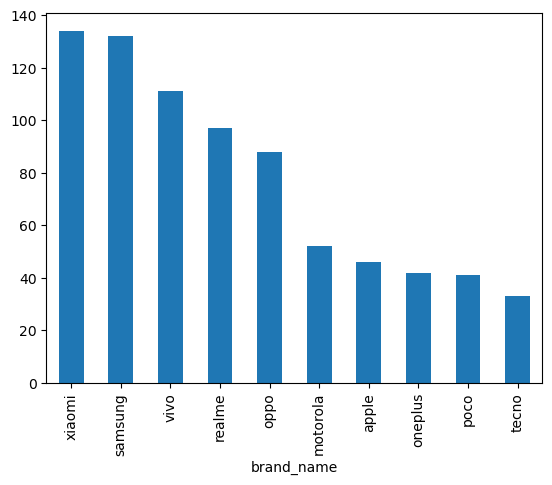

In [8]:
# plotting a graph of top 10 brand
df['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

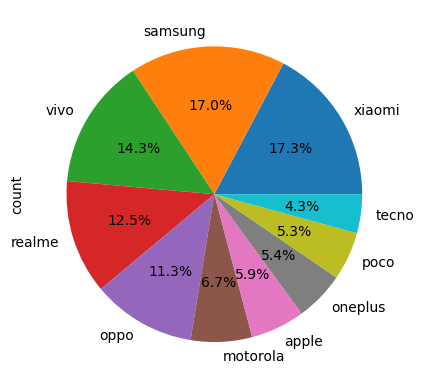

In [9]:
df['brand_name'].value_counts().head(10).plot(kind='pie',autopct='%0.1f%%')

In [10]:
# checking null values
df['brand_name'].isnull().sum()

np.int64(0)

#### model

**conclusions**

- No analysis currently , because of mixed value but supporting columns for others 

In [11]:
df['model'].nunique()

980

#### price
**conclusions**

- there are outliers
- distrubution is not normal
- Remove row price > 200000

In [12]:
df['price'].describe()

count       980.000000
mean      32520.504082
std       39531.812669
min        3499.000000
25%       12999.000000
50%       19994.500000
75%       35491.500000
max      650000.000000
Name: price, dtype: float64

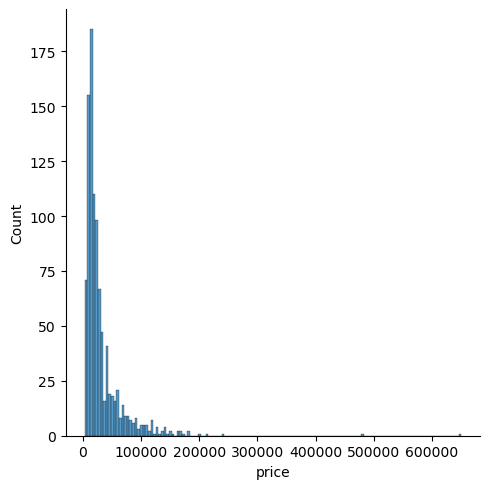

In [13]:
sns.displot(kind='hist',data=df,x='price')
# highly skewed data

In [14]:
df['price'].skew()

np.float64(6.591790999665567)

<Axes: ylabel='price'>

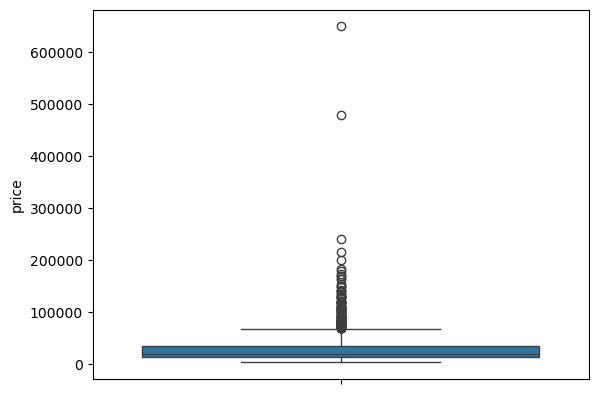

In [15]:
sns.boxplot(df['price'])

In [19]:
# outliers
df[df['price']>200000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
427,vertu,Vertu Signature Touch,650000,62.0,False,True,False,snapdragon,8.0,1.50,2275.0,0,NaN,2.0,64.0,4.70,1080 x 1920,60,1,1.0,android,13.0,2.1,0,NaN
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,False,True,True,snapdragon,8.0,3.20,4700.0,1,66.0,12.0,512.0,6.74,1212 x 2616,120,3,1.0,other,50.0,13.0,1,256.0
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,False,True,False,snapdragon,8.0,2.80,4000.0,1,27.0,8.0,256.0,6.39,1080 x 2340,60,3,1.0,android,48.0,20.0,0,NaN
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,True,True,True,kirin,8.0,2.86,4500.0,1,NaN,12.0,512.0,6.53,1176 x 2400,60,4,2.0,android,40.0,32.0,1,256.0


In [20]:
# checking null values
df['price'].isnull().sum()

np.int64(0)

#### rating
**conclusions**

- distribution near to normal
- 10% null values

In [21]:
df['rating'].describe()

count    879.000000
mean      78.258248
std        7.402854
min       60.000000
25%       74.000000
50%       80.000000
75%       84.000000
max       89.000000
Name: rating, dtype: float64

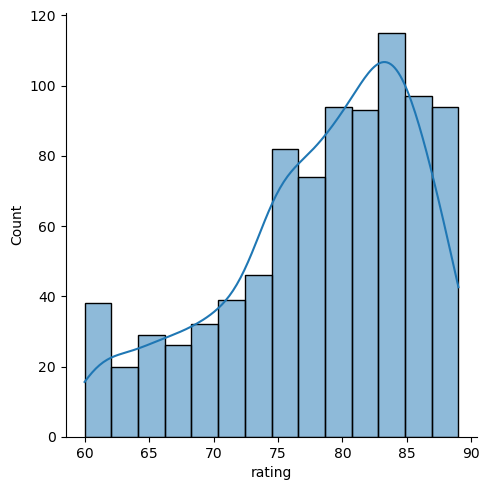

In [25]:
sns.displot(kind='hist',data=df,x='rating',kde=True)

In [27]:
df['rating'].skew()
# near to normal distribution

np.float64(-0.6989993034105535)

<Axes: ylabel='rating'>

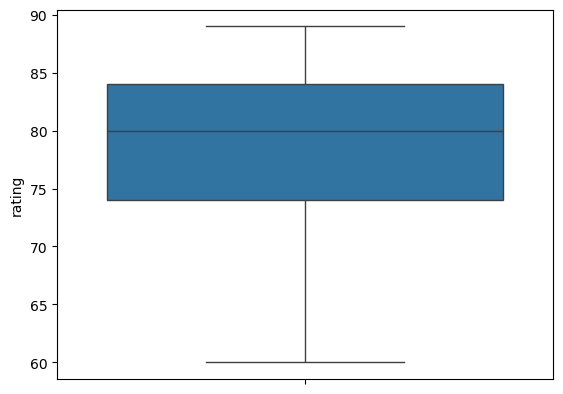

In [28]:
sns.boxplot(df['rating'])

In [29]:
# checking null values
df['rating'].isnull().sum()

np.int64(101)

#### has_5g
**conclusions**

- more phone has 5g 

<Axes: ylabel='count'>

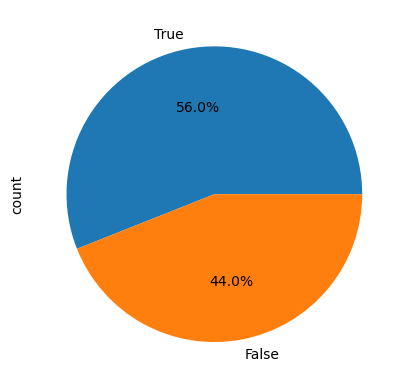

In [30]:
df['has_5g'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### has_nfc
**conclusions**

- lesser phone has nfc 

<Axes: ylabel='count'>

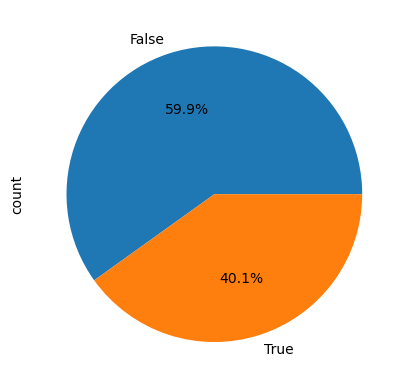

In [31]:
df['has_nfc'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### has_ir_blaster
**conclusions**

- Mostly chinese phone provide this feature

In [34]:
df[df['has_ir_blaster'] == True ]['brand_name'].value_counts()

brand_name
xiaomi     109
poco        30
iqoo         6
huawei       6
vivo         4
redmi        2
honor        1
samsung      1
Name: count, dtype: int64

#### processor_brand

<Axes: ylabel='count'>

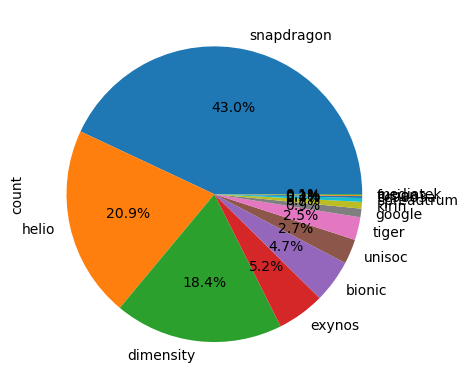

In [36]:
df['processor_brand'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### num_cores

<Axes: ylabel='count'>

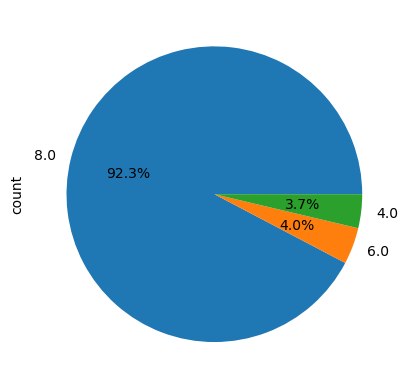

In [38]:
df['num_cores'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### fast_charging_available

<Axes: ylabel='count'>

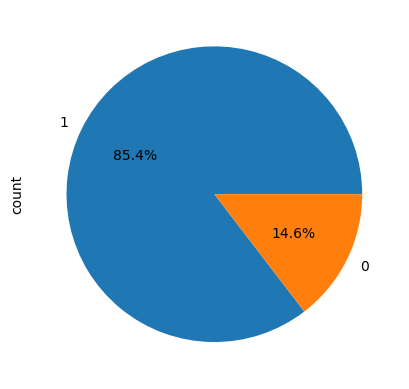

In [40]:
df['fast_charging_available'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### ram_capacity

<Axes: ylabel='count'>

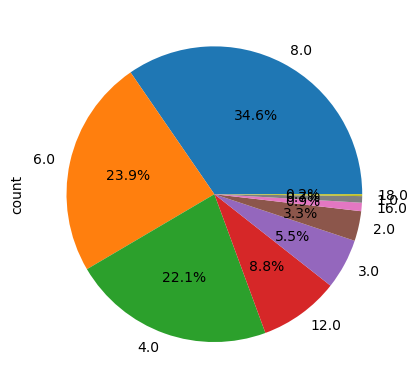

In [41]:
df['ram_capacity'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### internal_memory

<Axes: ylabel='count'>

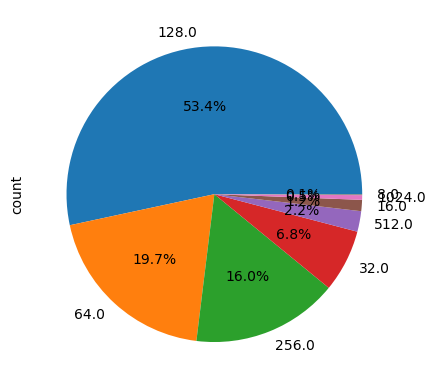

In [42]:
df['internal_memory'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### refresh_rate

<Axes: ylabel='count'>

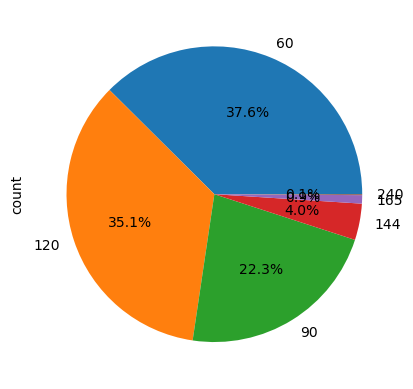

In [44]:
df['refresh_rate'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [50]:
df[df['refresh_rate']>=240]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
784,leitz,Leitz Phone 2,124990,89.0,True,True,False,snapdragon,8.0,3.0,5000.0,1,NaN,12.0,256.0,6.6,1260 x 2730,240,2,1.0,android,47.2,12.6,1,1024.0


#### num_cameras

<Axes: ylabel='count'>

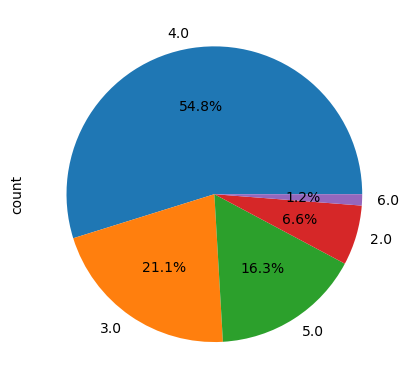

In [52]:
(df['num_front_cameras'] + df['num_rear_cameras']).value_counts().plot(kind='pie',autopct='%0.1f%%')

#### os

<Axes: ylabel='count'>

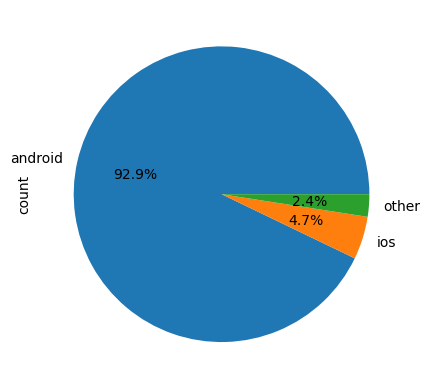

In [54]:
df['os'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### extended_memory_available

<Axes: ylabel='count'>

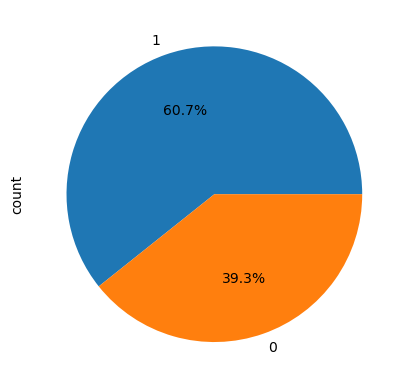

In [55]:
df['extended_memory_available'].value_counts().plot(kind='pie',autopct='%0.1f%%')

#### extended_upto

<Axes: ylabel='count'>

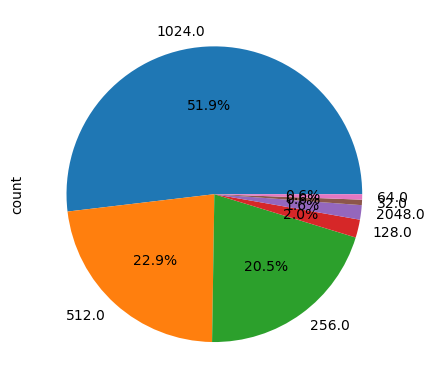

In [56]:
df['extended_upto'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Numerical Columns

In [72]:
# function for plotting graphs
def plot_graph(column_name):
    sns.displot(kind='hist',kde=True,data=df,x=column_name,label=column_name)
    sns.catplot(kind='box',data=df,x=column_name)

In [73]:
#Numerical columns
num_columns = df.select_dtypes(include=['float64','int64']).iloc[:,[3,4,6,9,13,14,16]].columns

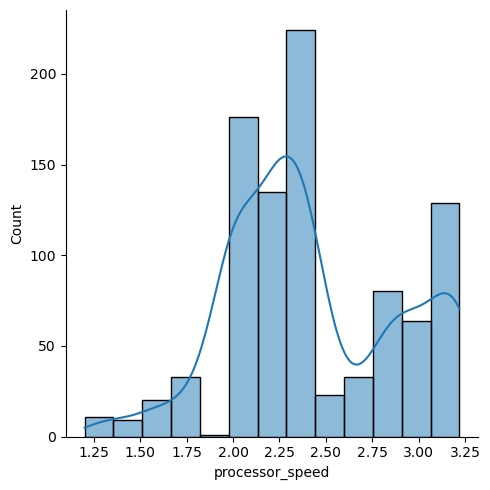

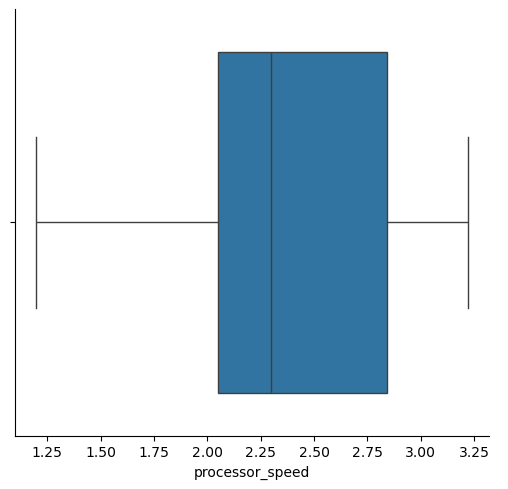

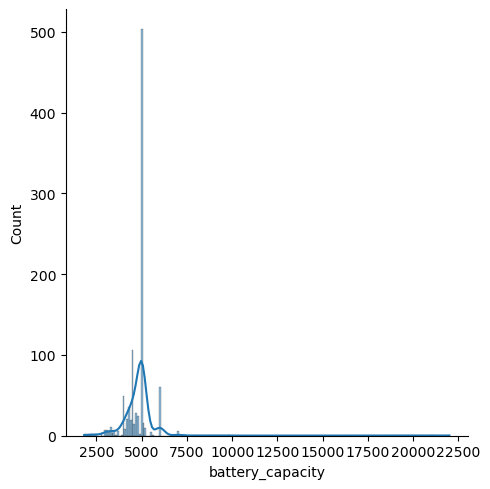

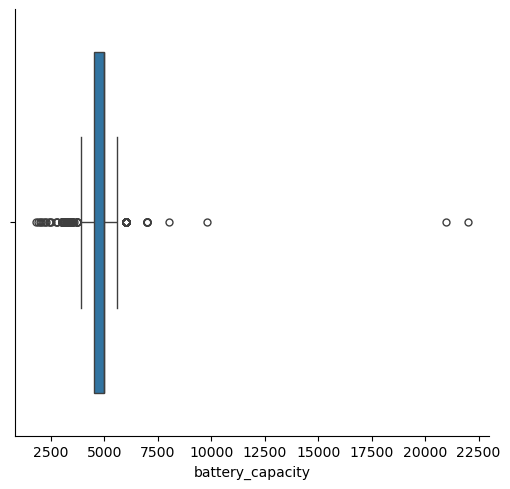

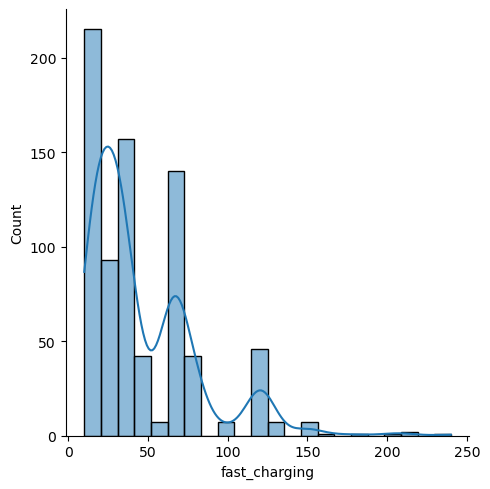

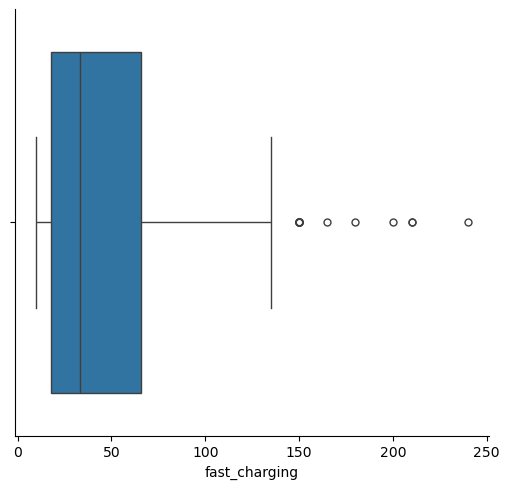

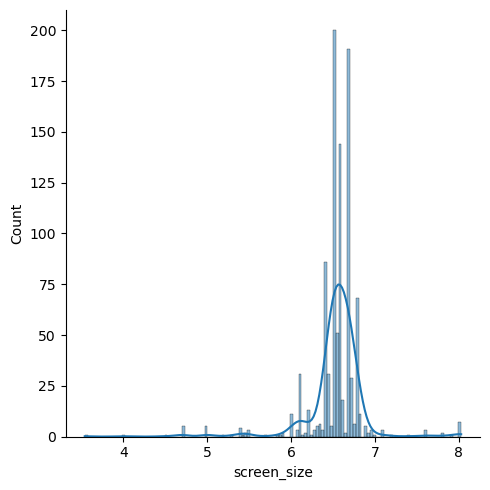

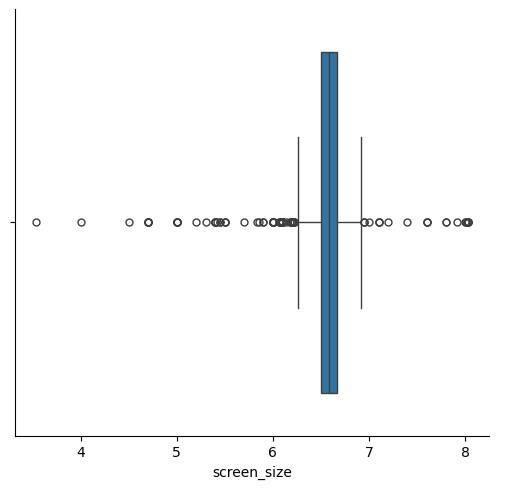

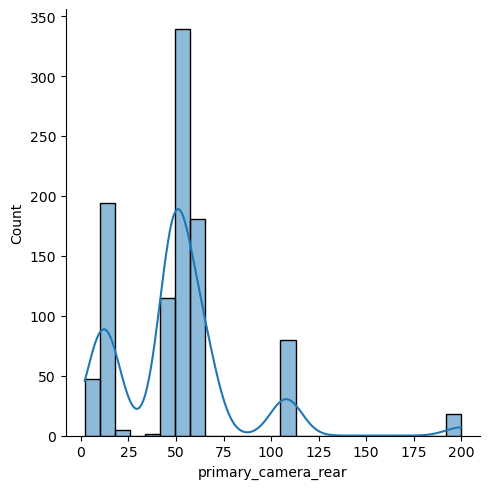

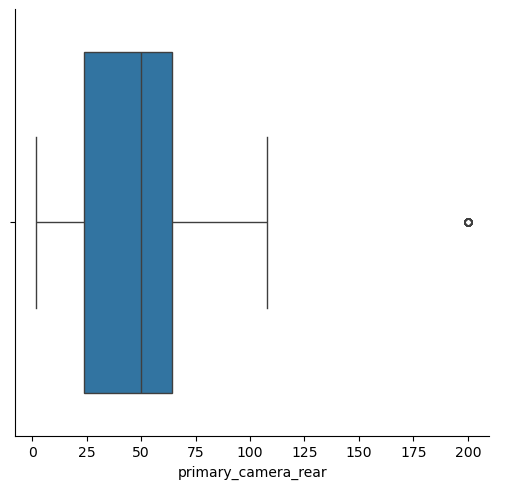

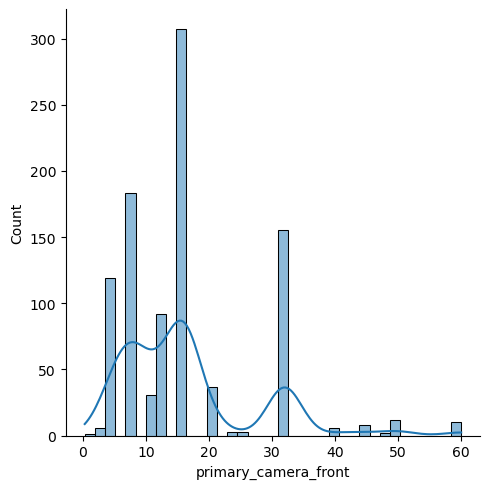

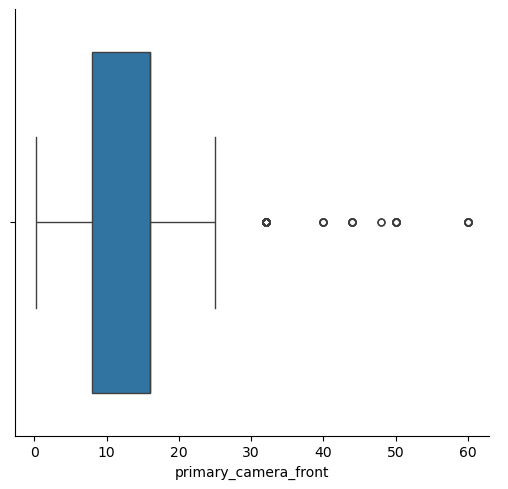

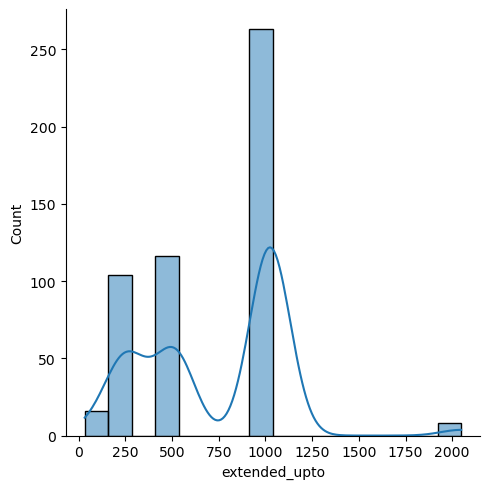

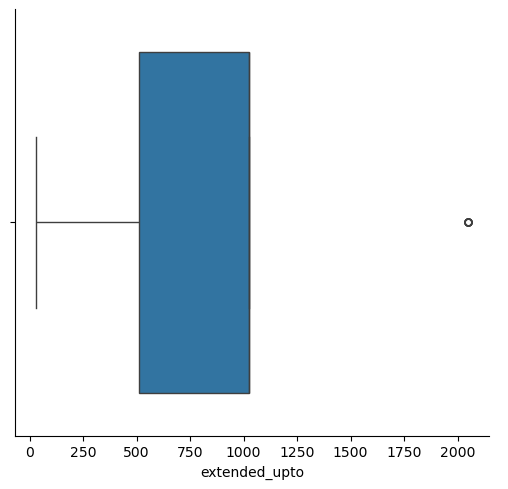

In [76]:
# Plotting All numerical col graph
for col in num_columns:
    plot_graph(col)

## Bivariate Analysis

#### brand & price

In [81]:
# filtering only brand with 10+ model
x = df.groupby('brand_name').count()['model']

In [88]:
temp_df = df[df['brand_name'].isin(x[x > 10].index)]
temp_df = temp_df.sort_values(by='brand_name')

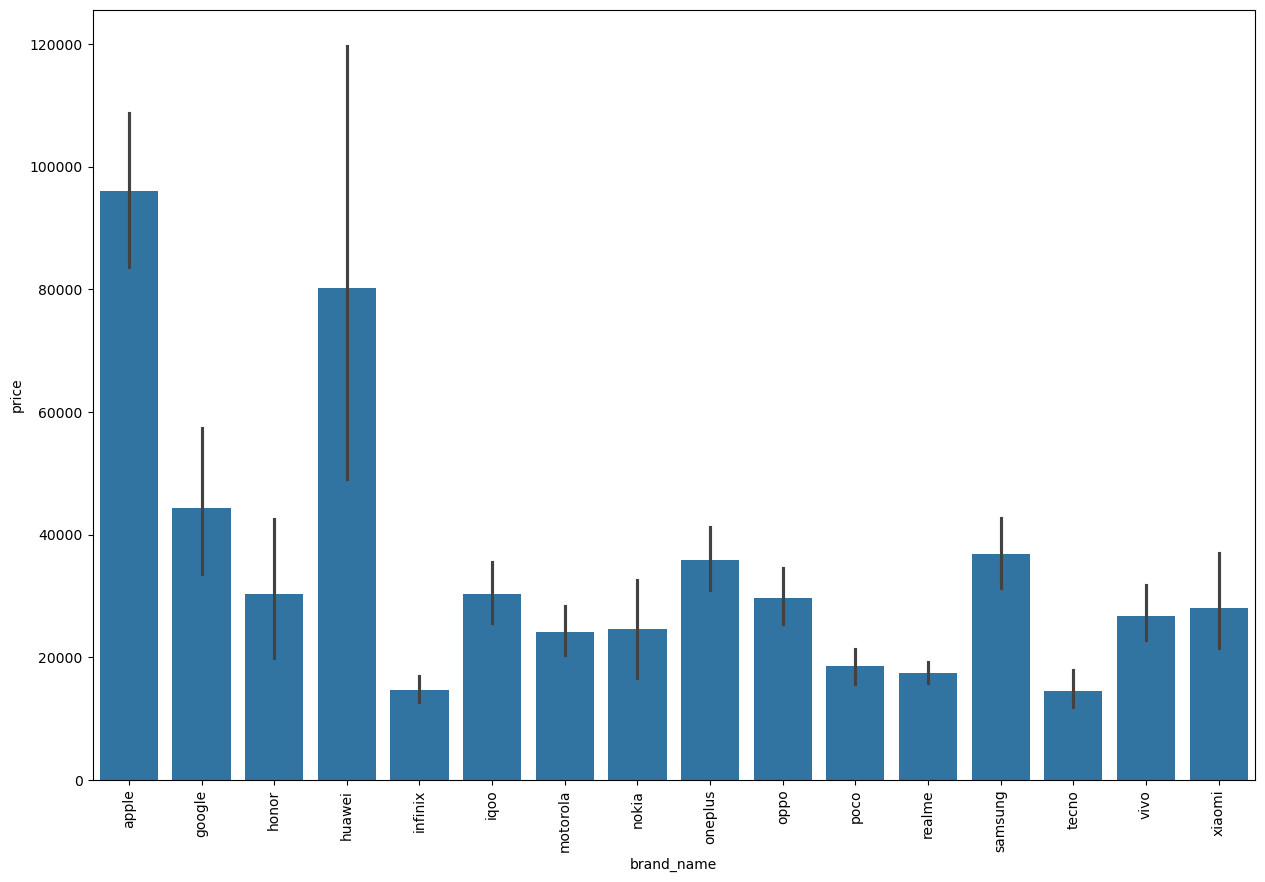

In [90]:
plt.figure(figsize=(15,10))
sns.barplot(data=temp_df,x='brand_name',y='price')
plt.xticks(rotation='vertical')
plt.show()

#### price & rating

<Axes: xlabel='rating', ylabel='price'>

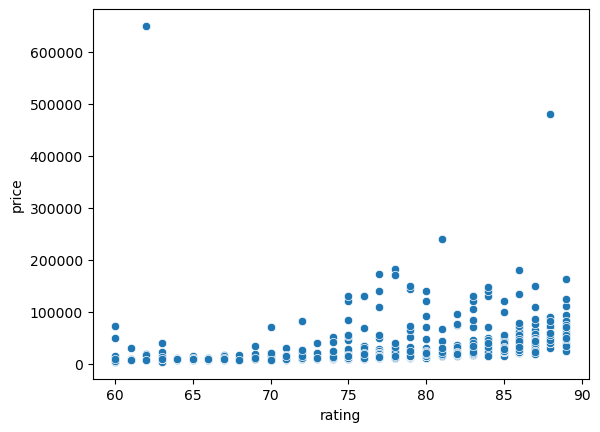

In [93]:
sns.scatterplot(data=df,x='rating',y='price')

#### price & has_5g

<Axes: xlabel='has_5g', ylabel='price'>

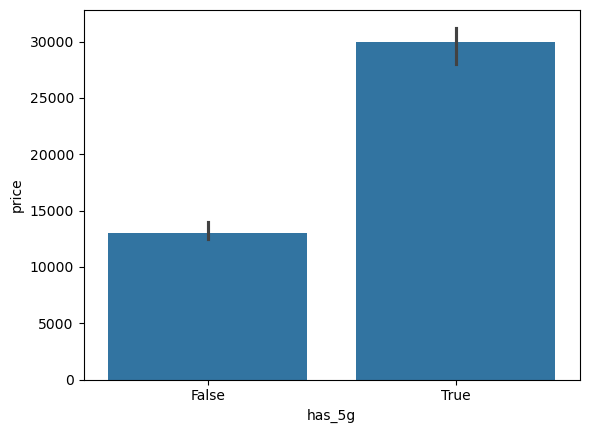

In [95]:
sns.barplot(data=temp_df,x='has_5g',y='price',estimator=np.median)

#### price & has_nfc

<Axes: xlabel='has_nfc', ylabel='price'>

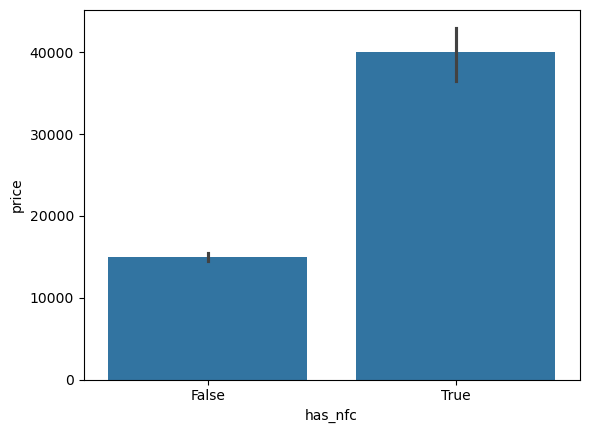

In [96]:
sns.barplot(data=temp_df,x='has_nfc',y='price',estimator=np.median)

#### price & has_ir_blaster

<Axes: xlabel='has_ir_blaster', ylabel='price'>

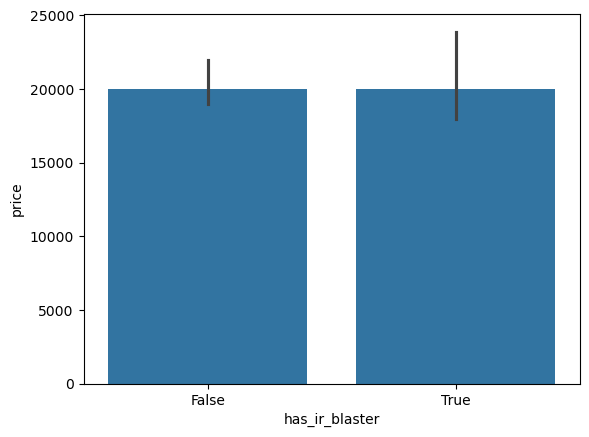

In [97]:
sns.barplot(data=temp_df,x='has_ir_blaster',y='price',estimator=np.median)

#### price & processor_brand

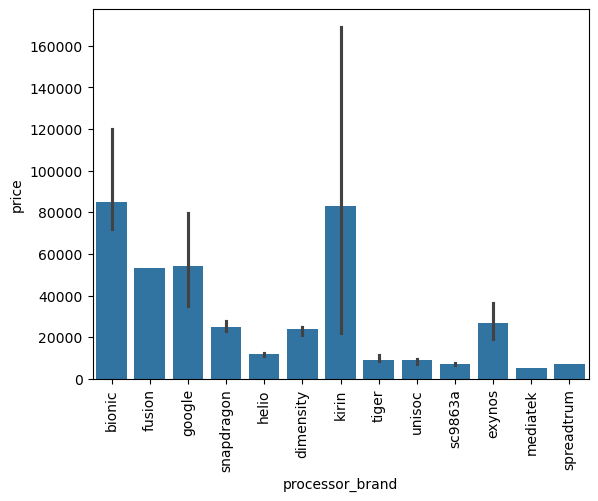

In [103]:
sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### price & num_cores

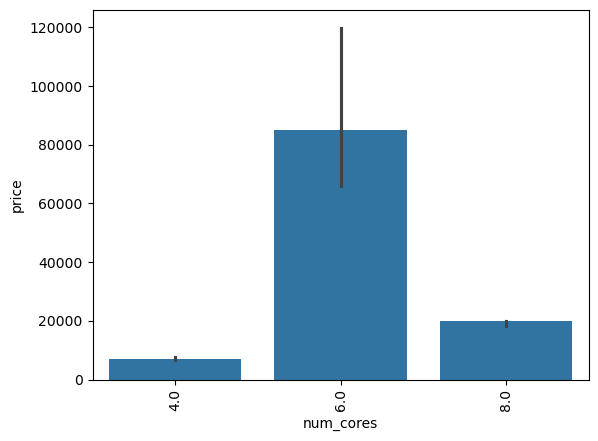

In [104]:
sns.barplot(data=temp_df,x='num_cores',y='price',estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### price & processor_speed

<Axes: xlabel='processor_speed', ylabel='price'>

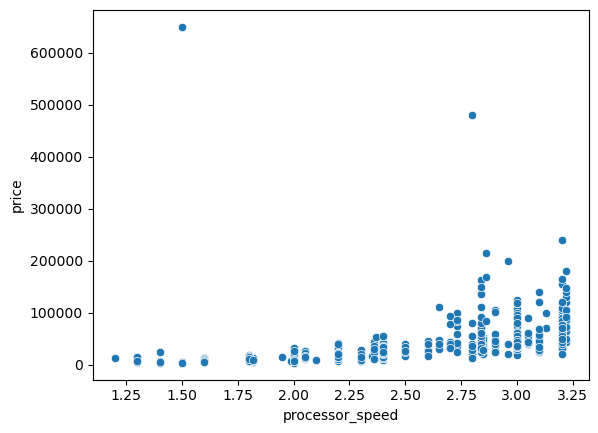

In [106]:
sns.scatterplot(data=df,x='processor_speed',y='price')

#### price & battery_capacity

<Axes: xlabel='battery_capacity', ylabel='price'>

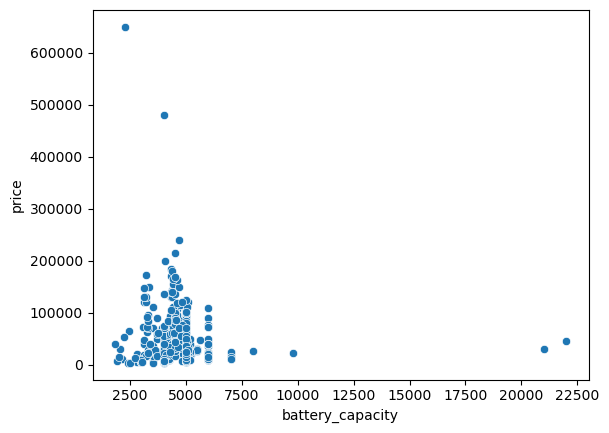

In [109]:
sns.scatterplot(data=df,x='battery_capacity',y='price')

#### price & ram_capacity

<Axes: xlabel='ram_capacity', ylabel='price'>

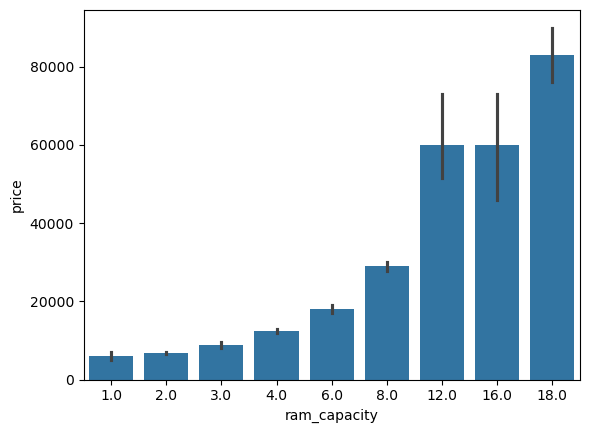

In [118]:
sns.barplot(data=df,x='ram_capacity',y='price',estimator=np.median)

#### price & internal_memory

<Axes: xlabel='internal_memory', ylabel='price'>

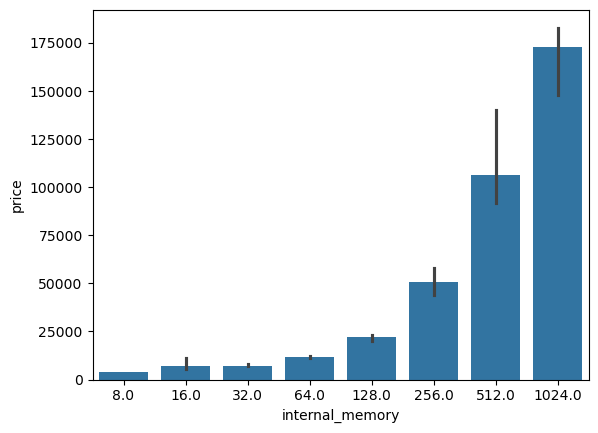

In [117]:
sns.barplot(data=df,x='internal_memory',y='price',estimator=np.median)

#### price & screen_size

<Axes: xlabel='screen_size', ylabel='price'>

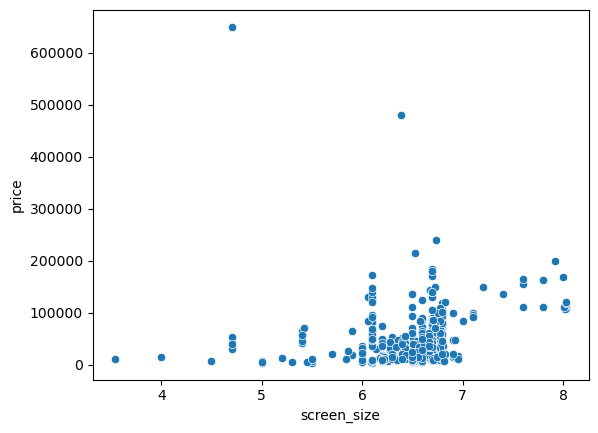

In [121]:
sns.scatterplot(data=df,x='screen_size',y='price')

#### price & refresh_rate

<Axes: xlabel='refresh_rate', ylabel='price'>

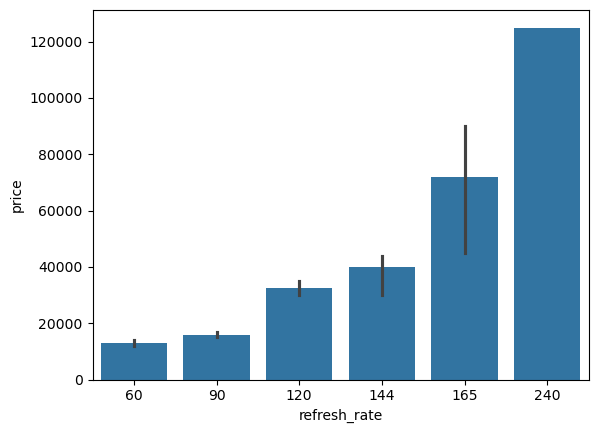

In [124]:
sns.barplot(data=df,x='refresh_rate',y='price',estimator=np.median)

#### price & num_rear_cameras

<Axes: xlabel='num_rear_cameras', ylabel='price'>

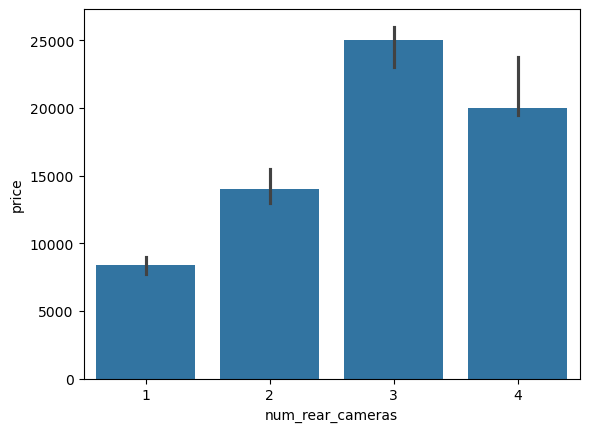

In [136]:
sns.barplot(data=df,x='num_rear_cameras',y='price',estimator=np.median)

#### price & num_front_camera

<Axes: xlabel='num_front_cameras', ylabel='price'>

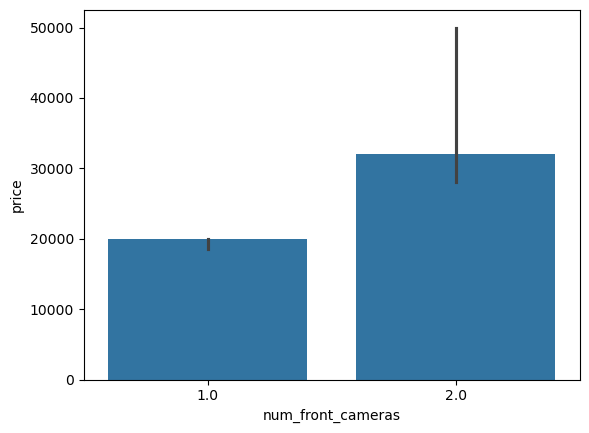

In [137]:
sns.barplot(data=df,x='num_front_cameras',y='price',estimator=np.median)

#### price & primary_camera_rear

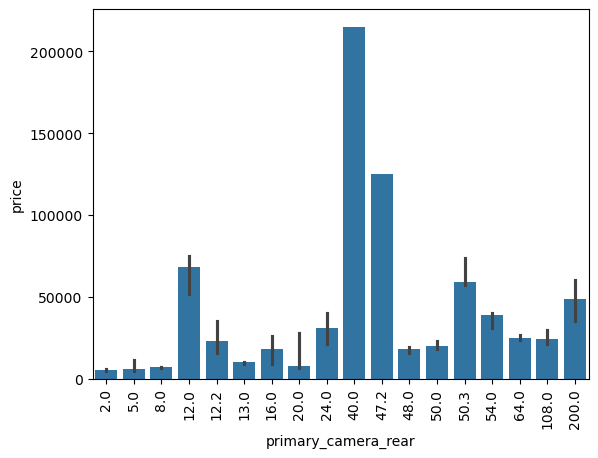

In [143]:
sns.barplot(data=df,x='primary_camera_rear',y='price',estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### price & primary_camera_front

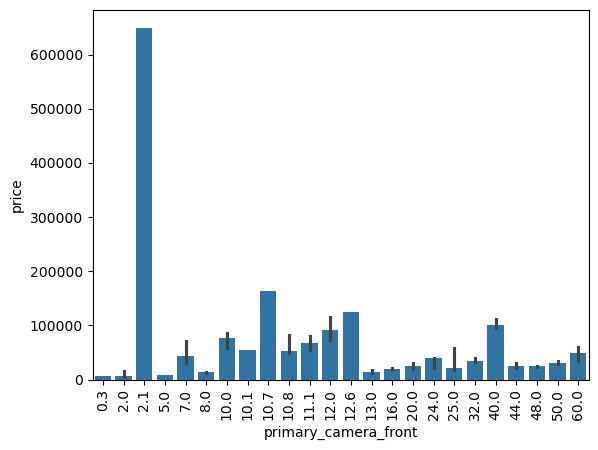

In [145]:
sns.barplot(data=df,x='primary_camera_front',y='price',estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### price & os

<Axes: xlabel='os', ylabel='price'>

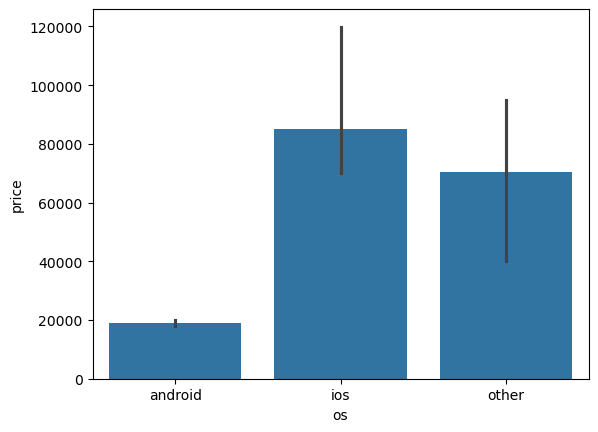

In [147]:
sns.barplot(data=df,x='os',y='price',estimator=np.median)

#### price & extented_memory_available

<Axes: xlabel='extended_memory_available', ylabel='price'>

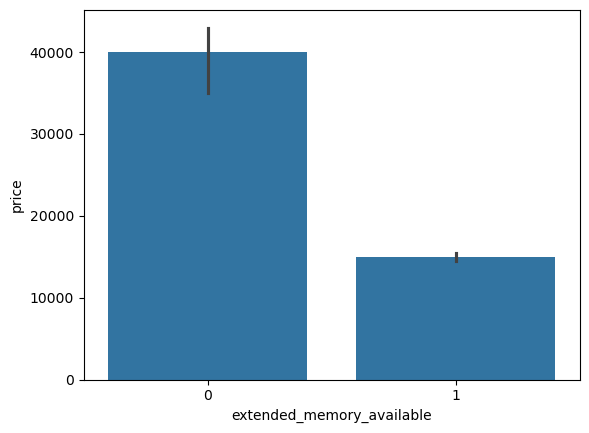

In [156]:
sns.barplot(data=df,x='extended_memory_available',y='price',estimator=np.median)

#### price & extented_upto

<Axes: xlabel='extended_upto', ylabel='price'>

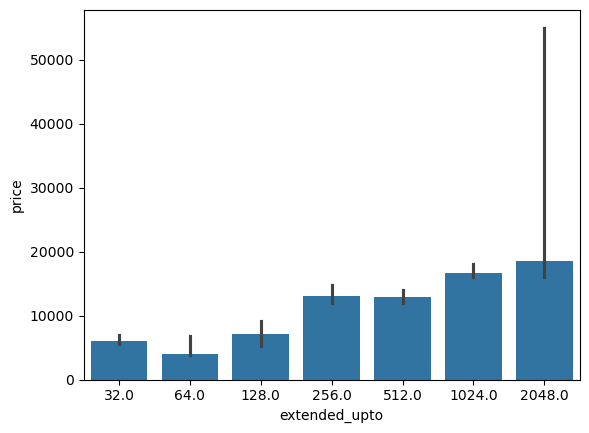

In [155]:
sns.barplot(data=df,x='extended_upto',y='price',estimator=np.median)

<Axes: >

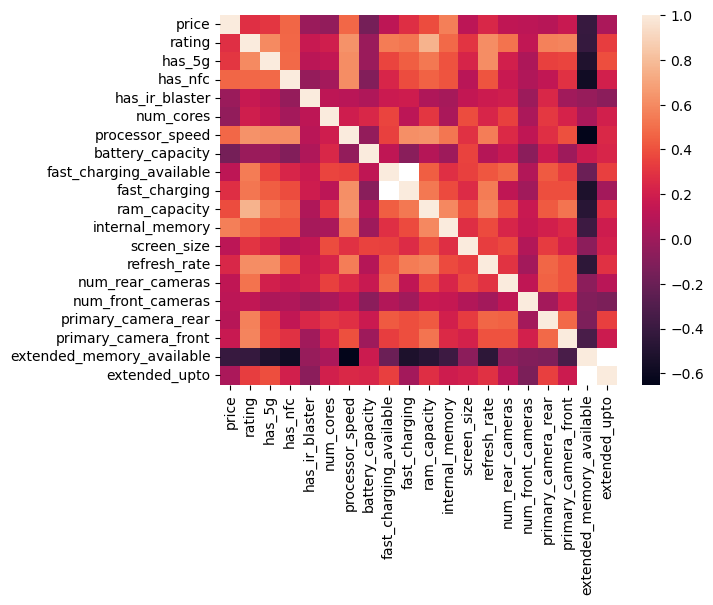

In [165]:
# To find relation between to columns use corr function
num_columns = df.select_dtypes(include=['float64','int64','bool'])
sns.heatmap(num_columns.corr())
# lighter shade show strong relation between two cols

In [167]:
# checking price relation with all columns
num_columns.corr()['price']

price                        1.000000
rating                       0.283504
has_5g                       0.305066
has_nfc                      0.470951
has_ir_blaster              -0.015807
num_cores                   -0.048561
processor_speed              0.474049
battery_capacity            -0.159232
fast_charging_available      0.116739
fast_charging                0.277591
ram_capacity                 0.386002
internal_memory              0.557168
screen_size                  0.113253
refresh_rate                 0.244115
num_rear_cameras             0.125330
num_front_cameras            0.115228
primary_camera_rear          0.092095
primary_camera_front         0.162995
extended_memory_available   -0.410798
extended_upto                0.048280
Name: price, dtype: float64

In [168]:
# checking null values
df.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                       101
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
resolution                     0
refresh_rate                   0
num_rear_cameras               0
num_front_cameras              4
os                             0
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                473
dtype: int64

In [172]:
# rating has null values | and it almost depends on all cols values
num_columns.corr()['rating']

price                        0.283504
rating                       1.000000
has_5g                       0.596087
has_nfc                      0.474754
has_ir_blaster               0.156421
num_cores                    0.199741
processor_speed              0.628446
battery_capacity            -0.015581
fast_charging_available      0.542814
fast_charging                0.527613
ram_capacity                 0.757613
internal_memory              0.481070
screen_size                  0.298272
refresh_rate                 0.610795
num_rear_cameras             0.515531
num_front_cameras            0.131480
primary_camera_rear          0.562046
primary_camera_front         0.577861
extended_memory_available   -0.416194
extended_upto                0.335471
Name: rating, dtype: float64

In [178]:
# we can fill null value on basis of other col data 
# through knn imputer

In [175]:
#knn imputer
df.shape

(980, 25)

In [176]:
x_df = df.select_dtypes(include=['int64','float64']).drop(columns='price')

In [179]:
from sklearn.impute import KNNImputer

In [180]:
imputer = KNNImputer(n_neighbors=5)

In [181]:
x_df_values = imputer.fit_transform(x_df)

In [182]:
x_df = pd.DataFrame(x_df_values,columns=x_df.columns)

In [183]:
x_df['price'] = df['price']